#  🧑‍🎓 Student-Dropout-Prediction_Logistic-Regression

## 📌 Problem Statement
Student dropout is a significant challenge for educational institutions, impacting both student outcomes and institutional performance. Early identification of at-risk students enables timely interventions and improves retention rates.
This project focuses on building a machine learning model to predict whether a student is likely to drop out based on academic performance and behavioral factors.

## 🎯 Goal
The primary goal is to develop a reliable and interpretable model that can identify students at risk of dropping out, enabling institutions to take proactive and data-driven decisions.

## 🎯 Objectives
- 📊 Perform exploratory data analysis to understand key patterns
- 🧠 Identify important features influencing student dropout
- 🤖 Build a logistic regression model 
- 📈 Evaluate model performance using multiple metrics
- ⚖️ Optimize predictions using threshold tuning

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [130]:
import warnings
warnings.filterwarnings('ignore')

## 🔍Data Overview 

In [131]:
df=pd.read_csv(r"../data/student_dropout_dataset.csv")
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [132]:
df.shape

(10000, 19)

In [133]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [135]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester_GPA', 'CGPA', 'Semester', 'Department',
       'Parental_Education', 'Dropout'],
      dtype='object')

In [136]:
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

We found missing values in Family_Income, Study_Hours, Stress_Index, and Parental_Education.
- Numerical: We use the Median to fill gaps as it is robust against outliers.
- Categorical: We use the Mode (most frequent value) for Parental_Education.

In [137]:
df.isnull().sum().sum()

np.int64(2011)

In [138]:
fill_columns=["Family_Income","Study_Hours_per_Day","Stress_Index"]

In [139]:
for col in fill_columns:
    df[col]=df[col].fillna(df[col].median())

In [140]:
df["Parental_Education"] = df["Parental_Education"].fillna(df["Parental_Education"].mode()[0])

In [141]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [142]:
df["Dropout"].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

- The dataset is moderately imbalanced with ~76% non-dropout and ~24% dropout cases. Accuracy alone will not be a reliable metric, so evaluation will include precision, recall, F1-score, and ROC-AUC.

## 📊 Exploratory Data Analysis

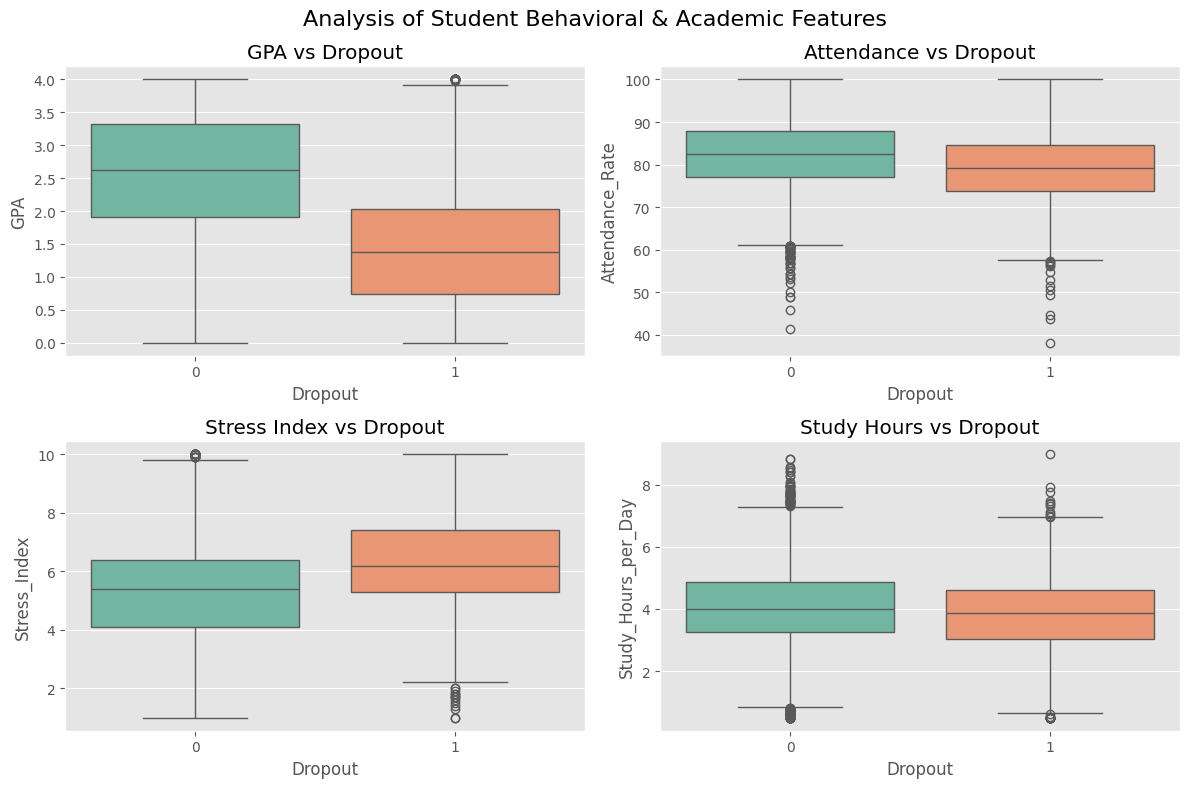

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x="Dropout", y="GPA", data=df, ax=axes[0,0],palette="Set2")
axes[0,0].set_title("GPA vs Dropout")

sns.boxplot(x="Dropout", y="Attendance_Rate", data=df, ax=axes[0,1],palette="Set2")
axes[0,1].set_title("Attendance vs Dropout")

sns.boxplot(x="Dropout", y="Stress_Index", data=df, ax=axes[1,0],palette="Set2")
axes[1,0].set_title("Stress Index vs Dropout")

sns.boxplot(x="Dropout", y="Study_Hours_per_Day", data=df, ax=axes[1,1],palette="Set2")
axes[1,1].set_title("Study Hours vs Dropout")

fig.suptitle('Analysis of Student Behavioral & Academic Features', fontsize=16,)
plt.tight_layout()
plt.show()

- GPA shows a strong separation between dropout and non-dropout students, indicating that academic performance is the most critical factor influencing student retention. Students with lower GPA are significantly more likely to drop out.
- Attendance and Stress Index show moderate differences, suggesting that while they impact dropout, there is some overlap between groups. This indicates that these factors contribute to dropout risk but are not solely decisive.
- Study Hours show relatively weak separation, implying that study time alone is not a strong predictor of dropout unless combined with other factors like performance and stress.
- Overall, academic performance (GPA) emerges as the dominant factor, while behavioral and psychological factors like attendance and stress provide additional predictive value.


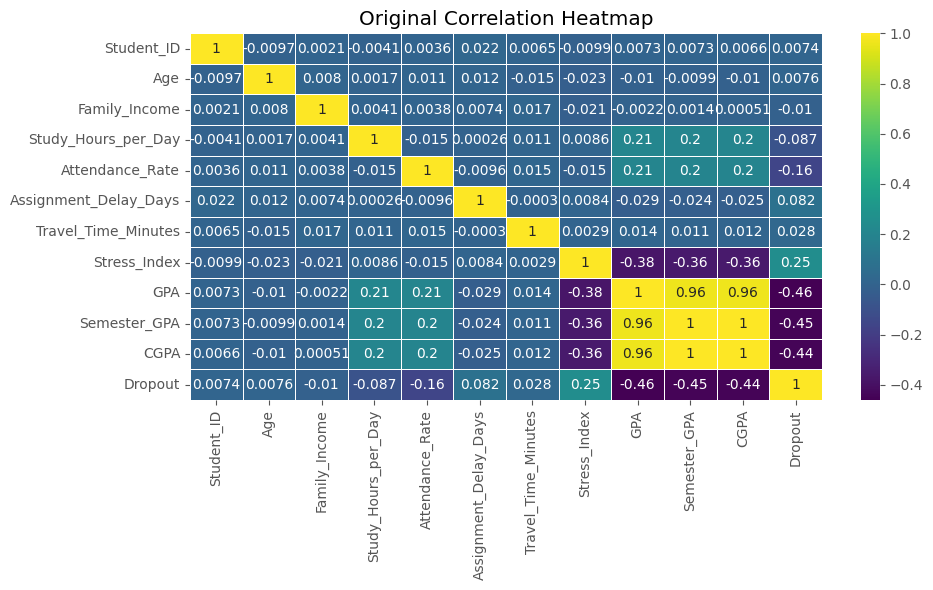

In [144]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Original Correlation Heatmap")
plt.tight_layout()
plt.show()

- High correlation was observed between GPA, Semester_GPA, and CGPA (correlation > 0.9).


In [145]:
df=df.drop(columns=["Semester_GPA","CGPA","Student_ID"])

In [146]:
df.columns

Index(['Age', 'Gender', 'Family_Income', 'Internet_Access',
       'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days',
       'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index',
       'GPA', 'Semester', 'Department', 'Parental_Education', 'Dropout'],
      dtype='object')

- Correlation analysis revealed a very high correlation (> 0.9) between GPA, Semester_GPA, and CGPA, indicating multicollinearity. Since these features carry similar information, retaining all of them can negatively impact model stability and interpretability.
- To address this, only GPA was retained as it reflects current academic performance, while Semester_GPA and CGPA were removed. Additionally, Student_ID was dropped as it does not contribute to prediction.

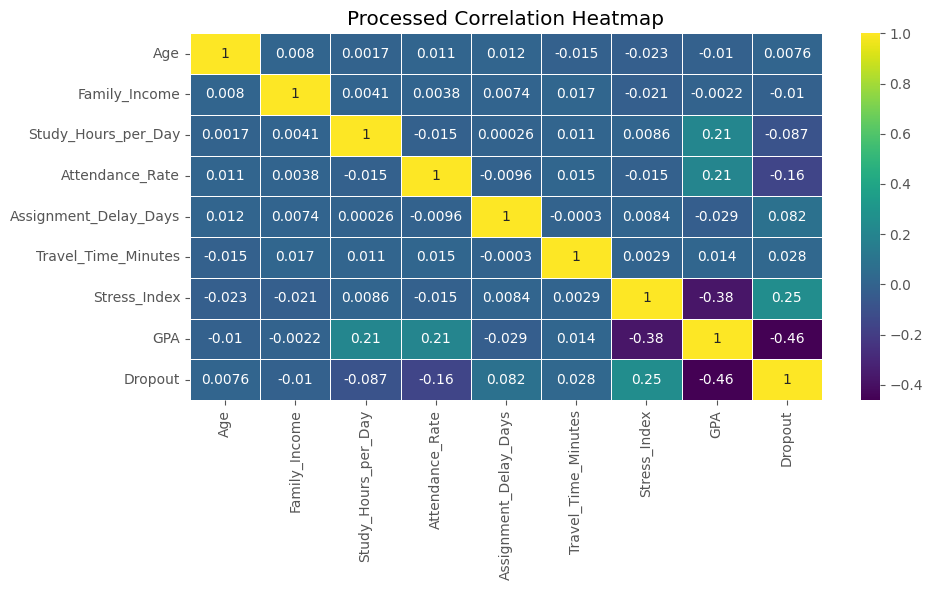

In [147]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis",linewidths=0.5)
plt.title("Processed Correlation Heatmap")
plt.tight_layout()
plt.show()

## ✂️ Train-Test Split

In [148]:
from sklearn.model_selection import train_test_split
X=df.drop("Dropout",axis=1)
y=df["Dropout"]

X_train,X_test,y_train,y_test=train_test_split(X , y , test_size=0.2,random_state=42,stratify=y)

In [149]:
y_train.value_counts(normalize=True)

Dropout
0    0.764625
1    0.235375
Name: proportion, dtype: float64

In [150]:
y_test.value_counts(normalize=True)

Dropout
0    0.7645
1    0.2355
Name: proportion, dtype: float64

- The dataset was divided into training and testing sets using an 80:20 ratio to evaluate the model's performance on unseen data.

- The dataset is moderately imbalanced (~76% non-dropout and ~24% dropout). To ensure both training and testing sets maintain the same class distribution, stratified sampling was applied. This helps in achieving a fair and reliable evaluation.

- The train-test split is performed after data cleaning and feature selection but before feature engineering, encoding, and scaling. This is done to prevent data leakage, ensuring that transformations applied later do not use information from the test set.


## ⚙️FEATURE ENGINEERING

### 1️⃣.Academic Risk

In [151]:
X_train["Academic_Risk"]=X_train["GPA"]*X_train["Attendance_Rate"]
X_test["Academic_Risk"]=X_test["GPA"]*X_test["Attendance_Rate"]

In [152]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424


- This feature combines GPA and attendance to capture overall academic performance. Students with low GPA and low attendance are more likely to drop out, and this interaction helps the model identify high-risk cases more effectively.
- **Impact** : Improves the model’s ability to detect students at academic risk by combining two important signals.


### 2️⃣.Effort_Ratio

In [153]:
X_train["Effort_Ratio"]=X_train["Study_Hours_per_Day"]/(X_train["GPA"]+1)
X_test["Effort_Ratio"]=X_test["Study_Hours_per_Day"]/(X_test["GPA"]+1)

In [154]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk,Effort_Ratio
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235,3.503704
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562,1.565611
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796,0.672414
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192,1.155063
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424,3.152778


- This feature represents the relationship between study effort and academic performance. It helps identify students who study more but still have low GPA, indicating inefficiency or learning difficulties. A constant (+1) is added to GPA to avoid division by zero and maintain stability.
- **Impact**: Helps detect mismatch between effort and performance, which can signal potential dropout risk.

### 3️⃣Stress_Impact

In [155]:
X_train["Stress_Impact"]=X_train["Stress_Index"]*(100-X_train["Attendance_Rate"])
X_test["Stress_Impact"]=X_test["Stress_Index"]*(100-X_test["Attendance_Rate"])

In [156]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Academic_Risk,Effort_Ratio,Stress_Impact
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,25.235,3.503704,270.63
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,111.562,1.565611,68.64
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,92.796,0.672414,139.59
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,186.192,1.155063,91.08
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,28.424,3.152778,223.02


- This feature combines stress level and attendance to capture behavioral risk. High stress along with low attendance indicates a higher likelihood of dropout, and this interaction makes the pattern more explicit.
- **Impact**: Enhances the model’s ability to identify students under high stress who are disengaging from classes.

In [157]:
X_train.shape

(8000, 18)

In [158]:
X_train.isnull().sum()

Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester                 0
Department               0
Parental_Education       0
Academic_Risk            0
Effort_Ratio             0
Stress_Impact            0
dtype: int64

### Correlation Analysis After Feature Engineering

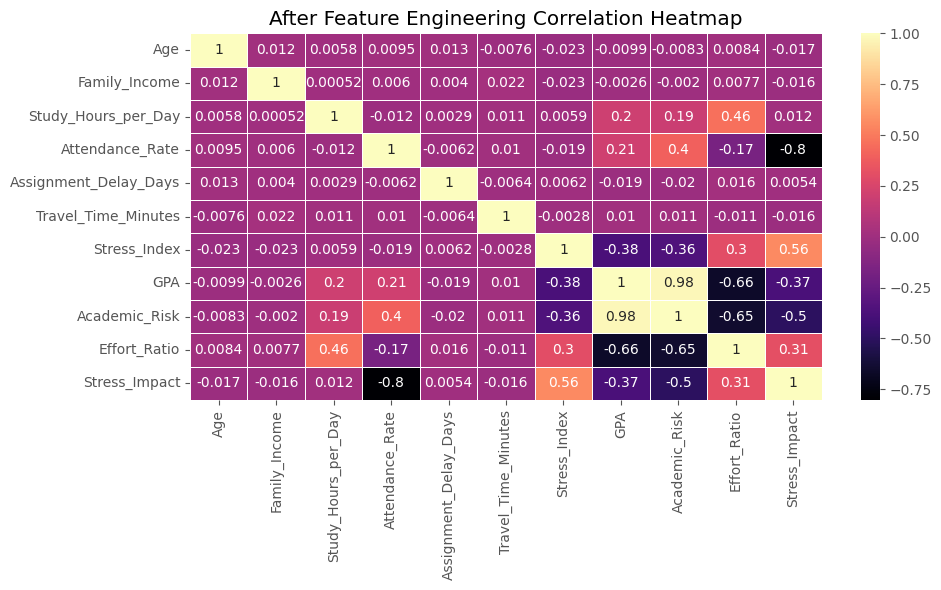

In [159]:
corr_matrix = X_train.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="magma",linewidths=0.5)
plt.title("After Feature Engineering Correlation Heatmap")
plt.tight_layout()
plt.show()

- The correlation heatmap was analyzed after creating new features to check for redundancy and multicollinearity. It was observed that Academic_Risk is highly correlated with GPA (~0.98), indicating that it does not provide additional information.
- Therefore, Academic_Risk was removed to avoid multicollinearity. Other engineered features like Effort_Ratio and Stress_Impact were retained as they show moderate correlation and capture different aspects of student behavior.

In [160]:
X_train=X_train.drop("Academic_Risk",axis=1)
X_test=X_test.drop("Academic_Risk",axis=1)

In [161]:
X_train.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester,Department,Parental_Education,Effort_Ratio,Stress_Impact
4565,19.7,Female,30092.0,Yes,4.73,72.1,3,7.7,Yes,Yes,9.7,0.35,Year 4,Engineering,Master,3.503704,270.63
3663,21.7,Female,71435.0,Yes,3.46,92.2,0,42.0,No,Yes,8.8,1.21,Year 3,CS,High School,1.565611,68.64
8964,22.5,Female,53704.0,Yes,1.56,70.3,4,30.0,No,No,4.7,1.32,Year 4,Science,High School,0.672414,139.59
5778,21.1,Male,31543.0,Yes,3.65,86.2,1,43.6,No,Yes,6.6,2.16,Year 3,Arts,Master,1.155063,91.08
9938,18.2,Female,25000.0,Yes,4.54,64.6,3,26.9,Yes,No,6.3,0.44,Year 1,Business,High School,3.152778,223.02


- Academic_Risk was removed because it showed a very high correlation with GPA (~0.98), indicating that it does not add new information and may cause multicollinearity.
- Effort_Ratio was retained as it captures the relationship between study effort and performance, providing additional insight beyond individual features.
- Stress_Impact was retained as it represents the interaction between stress and attendance, helping the model identify students at behavioral risk.
hese decisions ensure that only meaningful and non-redundant features are used for model training.


## 🔢 Categorical Feature Encoding

In [162]:
X_train=pd.get_dummies(X_train,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)

In [163]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [164]:
feature_names = X_train.columns

In [165]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [166]:
X_train.columns

Index(['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate',
       'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA',
       'Effort_Ratio', 'Stress_Impact', 'Gender_Male', 'Internet_Access_Yes',
       'Part_Time_Job_Yes', 'Scholarship_Yes', 'Semester_Year 2',
       'Semester_Year 3', 'Semester_Year 4', 'Department_Business',
       'Department_CS', 'Department_Engineering', 'Department_Science',
       'Parental_Education_High School', 'Parental_Education_Master',
       'Parental_Education_PhD'],
      dtype='object')

In [167]:
X_train.head(3)

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Effort_Ratio,Stress_Impact,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
4565,19,30092,4,72,3,7,9,0,3,270,...,0,0,1,0,0,1,0,0,1,0
3663,21,71435,3,92,0,42,8,1,1,68,...,0,1,0,0,1,0,0,1,0,0
8964,22,53704,1,70,4,30,4,1,0,139,...,0,0,1,0,0,0,1,1,0,0


- Categorical features were converted into numerical format using one-hot encoding, as model require numeric input. Label encoding was not used to avoid introducing incorrect ordinal relationships between categories.

## 🔢 Feature Scaling 

In [168]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

- Numerical features were scaled using StandardScaler to bring all features to a similar scale. The scaler was fitted only on the training data and then applied to both training and testing sets to prevent data leakage.

In [181]:
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

## 🤖 Model Training (Logistic Regression)

In [170]:
from sklearn.linear_model import LogisticRegression

In [171]:
model=LogisticRegression(class_weight="balanced",max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


- A Logistic Regression model was trained using the processed dataset. Class weights were balanced to handle class imbalance, and sufficient iterations were used to ensure proper convergence.

In [182]:
model.coef_

array([[ 0.02329412, -0.04971621, -0.20306506, -0.00644313,  0.23043253,
         0.12820161,  0.13413664, -0.95906706,  0.27252198,  0.32506115,
        -0.02165944, -0.09703969,  0.0982617 , -0.00860382,  0.08092379,
         0.0751225 ,  0.05926098, -0.01789277, -0.0619047 , -0.0239483 ,
        -0.05221239,  0.01714515, -0.05698195, -0.00164702]])

### Feature Importance 

In [183]:
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_[0]})
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)
feature_importance

,Feature,Coefficient
9,Stress_Impact,0.325061
8,Effort_Ratio,0.272522
4,Assignment_Delay_Days,0.230433
6,Stress_Index,0.134137
5,Travel_Time_Minutes,0.128202
12,Part_Time_Job_Yes,0.098262
14,Semester_Year 2,0.080924
15,Semester_Year 3,0.075122
16,Semester_Year 4,0.059261
0,Age,0.023294


From the model coefficients, several key patterns can be observed:
- Stress_Impact, Effort_Ratio, and Assignment_Delay_Days have strong positive coefficients, indicating that higher stress, inefficient effort, and delayed assignments significantly increase the likelihood of student dropout.
- Stress_Index and Travel_Time also contribute positively, suggesting that external pressures and commute time influence student performance and retention.
- On the other hand, GPA and Study_Hours_per_Day have strong negative coefficients, meaning that better academic performance and consistent study habits significantly reduce dropout risk.
- Features like Internet Access and Family Income also show negative influence, indicating that better resources and support systems help students continue their education.
- Overall, academic performance and stress-related factors emerge as the most critical drivers of student dropout.

In [172]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

- The trained model was used to generate class predictions and probability scores for the test dataset. Probability scores are useful for evaluating model performance using advanced metrics.

## 📈 Model Evaluation 

In [173]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7325
Precision: 0.458005249343832
Recall: 0.7409766454352441
F1 Score: 0.5660989456609895
ROC-AUC: 0.8160170184639781


In [174]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1116  413]
 [ 122  349]]


- The model was evaluated using multiple performance metrics including accuracy, precision, recall, F1-score, and ROC-AUC. The results show that the model achieves good recall, indicating its effectiveness in identifying dropout students, while precision is relatively lower due to false positives.
- A confusion matrix was also used to analyze prediction errors in detail. It shows that while the model correctly identifies most dropout cases, there are a significant number of false positive predictions, suggesting scope for improvement through threshold tuning.

## ⚖️ Threshold Tuning

In [175]:
for t in [0.5,0.6,0.7]:
    y_pred_new = (y_prob > t).astype(int)
    print("threshold",t)
    print("Accuracy:", accuracy_score(y_test, y_pred_new))
    print("Precision:", precision_score(y_test, y_pred_new))
    print("Recall:", recall_score(y_test, y_pred_new))
    print("F1 Score:", f1_score(y_test, y_pred_new))
    print()

threshold 0.5
Accuracy: 0.7325
Precision: 0.458005249343832
Recall: 0.7409766454352441
F1 Score: 0.5660989456609895

threshold 0.6
Accuracy: 0.7895
Precision: 0.5446428571428571
Recall: 0.6475583864118896
F1 Score: 0.5916585838991271

threshold 0.7
Accuracy: 0.811
Precision: 0.6267029972752044
Recall: 0.4883227176220807
F1 Score: 0.548926014319809



- Different threshold values (0.5, 0.6, 0.7) were evaluated to analyze the trade-off between precision and recall.
- At 0.5, recall is high but precision is low, leading to many false positive predictions.
- At 0.7, precision improves but recall drops significantly, causing the model to miss many actual dropout students.
- At 0.6, a good balance is achieved between precision and recall, resulting in the highest F1 score.
- Therefore, 0.6 was selected as the optimal threshold as it provides a balanced and reliable performance for dropout prediction.

In [176]:
y_pred_new=(y_prob>0.6).astype(int)

In [177]:
cm=confusion_matrix(y_test,y_pred_new)
print(cm)

[[1274  255]
 [ 166  305]]


After applying the selected threshold (0.6), the confusion matrix was evaluated to analyze prediction performance.

It was observed that:

- False Positives reduced compared to threshold 0.5, indicating fewer incorrect dropout predictions.
- False Negatives slightly increased, meaning a few more actual dropout students were missed.
- True Negatives increased, improving overall prediction reliability.

This confirms that the chosen threshold (0.6) provides a better balance by reducing false alarms while maintaining acceptable detection of dropout students.

## 🔧 Regularization Tuning

In [178]:
for c in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=c, class_weight='balanced', max_iter=1000)
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.6).astype(int)
    
    print("C:", c)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print()

C: 0.01
Precision: 0.5496323529411765
Recall: 0.6348195329087049
F1: 0.5891625615763547

C: 0.1
Precision: 0.5457809694793537
Recall: 0.6454352441613588
F1: 0.5914396887159533

C: 1
Precision: 0.5446428571428571
Recall: 0.6475583864118896
F1: 0.5916585838991271

C: 10
Precision: 0.5446428571428571
Recall: 0.6475583864118896
F1: 0.5916585838991271

C: 100
Precision: 0.5446428571428571
Recall: 0.6475583864118896
F1: 0.5916585838991271



- Different values of the regularization parameter (C) were tested to improve model performance. However, it was observed that changes in C did not significantly affect precision, recall, or F1 score.
- This indicates that the model has already learned the underlying patterns effectively, and further improvement through regularization is limited.

### 📊 ROC Curve Analysis

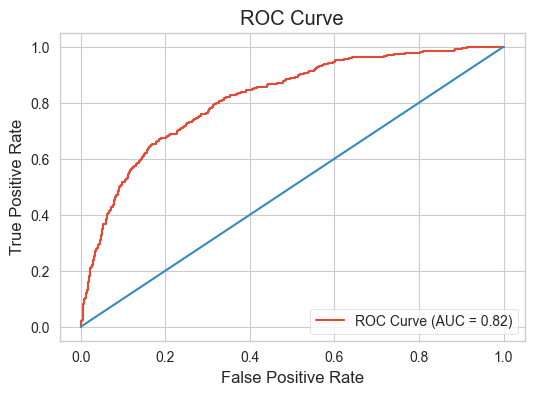

In [179]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

- The ROC curve was plotted to evaluate the model’s ability to distinguish between dropout and non-dropout students across different threshold values.
- The model achieved a ROC-AUC score of approximately 0.82, indicating good classification performance. The curve lies well above the diagonal baseline, confirming that the model performs significantly better than random guessing and has strong discriminative capability.

## 📊 Confusion Matrix Analysis

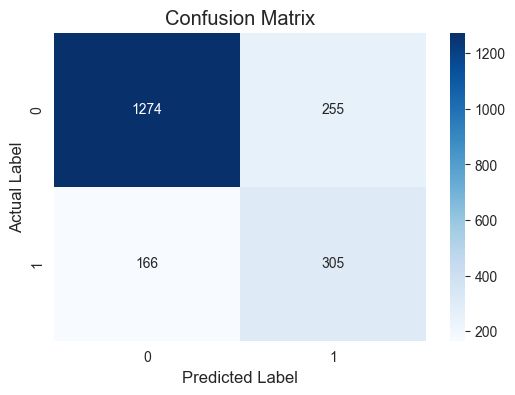

In [180]:
cm = confusion_matrix(y_test, y_pred_new)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

- The confusion matrix at the optimized threshold (0.6) shows that the model performs well in correctly classifying non-dropout students, while also identifying a substantial number of actual dropout cases.
- Although some false positives are present, indicating that a few non-dropout students are flagged as at risk, this trade-off helps improve the model’s ability to detect dropout cases. A limited number of false negatives remain, meaning some dropout students are not captured.
- Overall, the model demonstrates a balanced performance, effectively managing the trade-off between recall and precision, and is suitable for identifying at-risk students in a practical setting.